In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set professional plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Read data
df = pd.read_csv('../results/mpi_weak_results.csv')
print("MPI Weak Scaling Data (Constant Work per Node):")
print(df)

MPI Weak Scaling Data (Constant Work per Node):
   Nodes  Tasks  ThreadsPerTask  GridX  GridY  TotalTime  CommTime  CompTime  \
0      1      1             128   2000   2000   0.366327  0.037942  0.137329   
1      2      2             128   2828   2828   0.348329  0.056022  0.143456   
2      4      4             128   4000   4000   0.332119  0.075196  0.145727   

   Efficiency  
0      1.0000  
1      1.0516  
2      1.1029  


✅ Saved: mpi_weak_efficiency.png


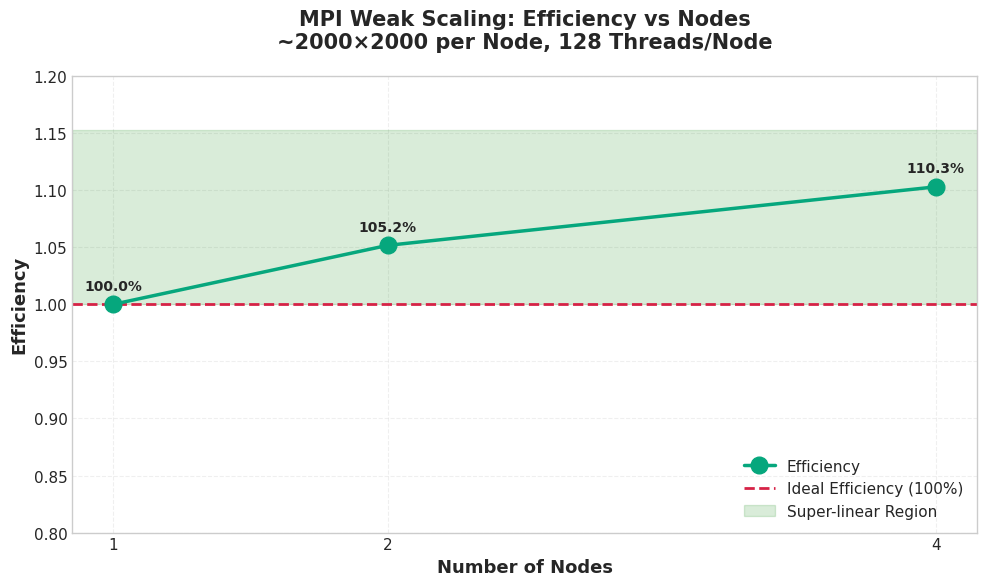

In [ ]:
# ============================================================================
# PLOT 1: Efficiency vs Nodes (Weak Scaling)
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['Nodes'], df['Efficiency'], 
        'o-', linewidth=2.5, markersize=12, 
        color='#06A77D', label='Efficiency', zorder=3)

# Ideal efficiency line
ax.axhline(y=1.0, color='#D62246', linestyle='--', linewidth=2, label='Ideal Efficiency (100%)', zorder=2)

ax.set_xlabel('Number of Nodes', fontsize=13, fontweight='bold')
ax.set_ylabel('Efficiency', fontsize=13, fontweight='bold')
ax.set_title('MPI Weak Scaling: Efficiency vs Nodes\n~2000×2000 per Node, 128 Threads/Node', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='lower right')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(df['Nodes'])
ax.set_xticklabels(df['Nodes'])
ax.set_ylim([0.8, 1.2])

# Highlight super-linear efficiency
if df['Efficiency'].max() > 1.0:
    ax.axhspan(1.0, df['Efficiency'].max() + 0.05, alpha=0.15, color='green', 
               label='Super-linear Region')
    ax.legend(fontsize=11, loc='lower right')

# Add percentage labels
for i, row in df.iterrows():
    ax.text(row['Nodes'], row['Efficiency'] + 0.01, 
            f"{row['Efficiency']*100:.1f}%",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('img/mpi_weak_efficiency.png', dpi=300, bbox_inches='tight')
print("✅ Saved: mpi_weak_efficiency.png")
plt.show()


✅ Saved: mpi_weak_totaltime.png


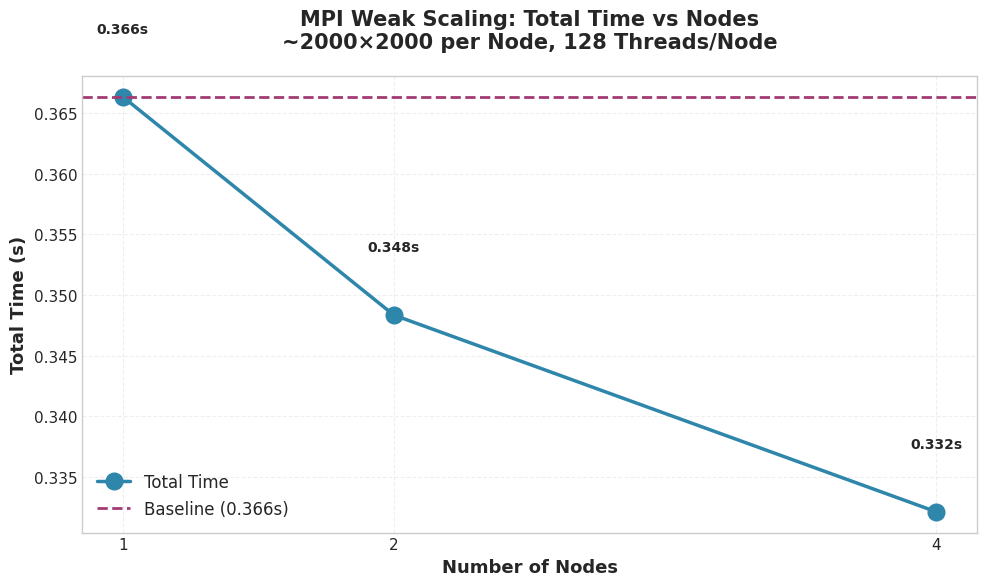

In [ ]:
# ============================================================================
# PLOT 2: Total Time vs Nodes (Should be ~constant)
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['Nodes'], df['TotalTime'], 
        'o-', linewidth=2.5, markersize=12, 
        color='#2E86AB', label='Total Time')

# Show baseline (ideal = constant)
baseline = df.iloc[0]['TotalTime']
ax.axhline(y=baseline, color='#A23B72', linestyle='--', linewidth=2, 
           label=f'Baseline ({baseline:.3f}s)')

ax.set_xlabel('Number of Nodes', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Time (s)', fontsize=13, fontweight='bold')
ax.set_title('MPI Weak Scaling: Total Time vs Nodes\n~2000×2000 per Node, 128 Threads/Node', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(df['Nodes'])
ax.set_xticklabels(df['Nodes'])

# Add value labels
for i, row in df.iterrows():
    ax.text(row['Nodes'], row['TotalTime'] + 0.005, 
            f"{row['TotalTime']:.3f}s",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('img/mpi_weak_totaltime.png', dpi=300, bbox_inches='tight')
print("✅ Saved: mpi_weak_totaltime.png")
plt.show()

✅ Saved: mpi_weak_commtime.png


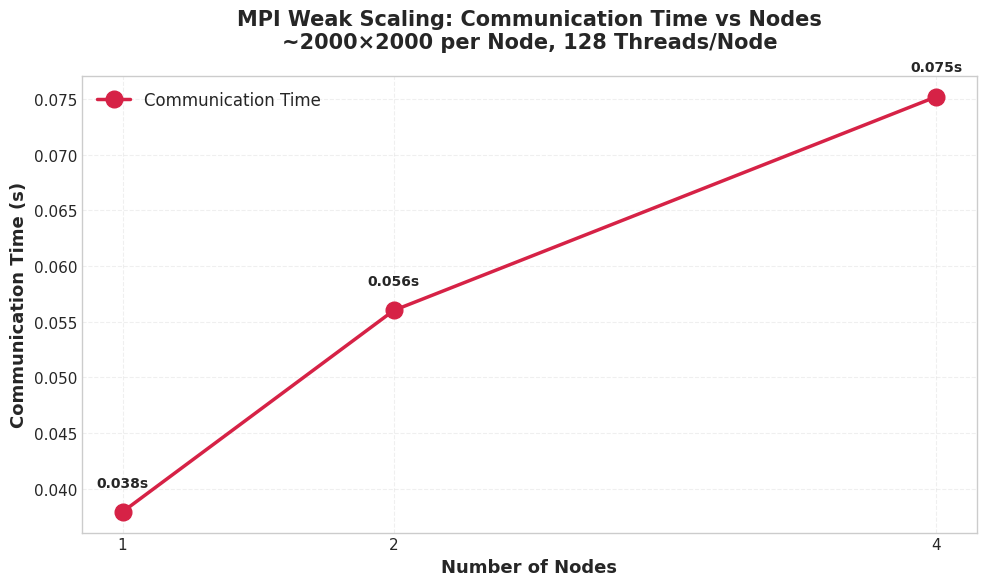

In [ ]:
# ============================================================================
# PLOT 3: Communication Time vs Nodes
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['Nodes'], df['CommTime'], 
        'o-', linewidth=2.5, markersize=12, 
        color='#D62246', label='Communication Time')

ax.set_xlabel('Number of Nodes', fontsize=13, fontweight='bold')
ax.set_ylabel('Communication Time (s)', fontsize=13, fontweight='bold')
ax.set_title('MPI Weak Scaling: Communication Time vs Nodes\n~2000×2000 per Node, 128 Threads/Node', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(df['Nodes'])
ax.set_xticklabels(df['Nodes'])

# Add value labels
for i, row in df.iterrows():
    ax.text(row['Nodes'], row['CommTime'] + 0.002, 
            f"{row['CommTime']:.3f}s",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('img/mpi_weak_commtime.png', dpi=300, bbox_inches='tight')
print("✅ Saved: mpi_weak_commtime.png")
plt.show()

✅ Saved: mpi_weak_comptime.png


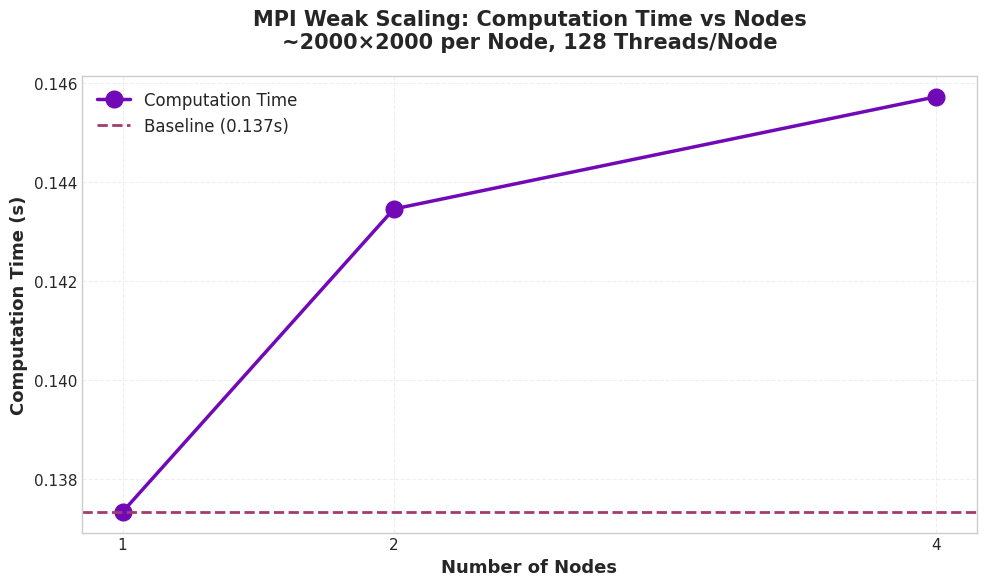

In [ ]:
# ============================================================================
# PLOT 4: Computation Time vs Nodes
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['Nodes'], df['CompTime'], 
        'o-', linewidth=2.5, markersize=12, 
        color='#7209B7', label='Computation Time')

# Baseline
comp_baseline = df.iloc[0]['CompTime']
ax.axhline(y=comp_baseline, color='#A23B72', linestyle='--', linewidth=2, 
           label=f'Baseline ({comp_baseline:.3f}s)')

ax.set_xlabel('Number of Nodes', fontsize=13, fontweight='bold')
ax.set_ylabel('Computation Time (s)', fontsize=13, fontweight='bold')
ax.set_title('MPI Weak Scaling: Computation Time vs Nodes\n~2000×2000 per Node, 128 Threads/Node', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(df['Nodes'])
ax.set_xticklabels(df['Nodes'])

plt.tight_layout()
plt.savefig('img/mpi_weak_comptime.png', dpi=300, bbox_inches='tight')
print("✅ Saved: mpi_weak_comptime.png")
plt.show()

✅ Saved: mpi_weak_gridsize.png


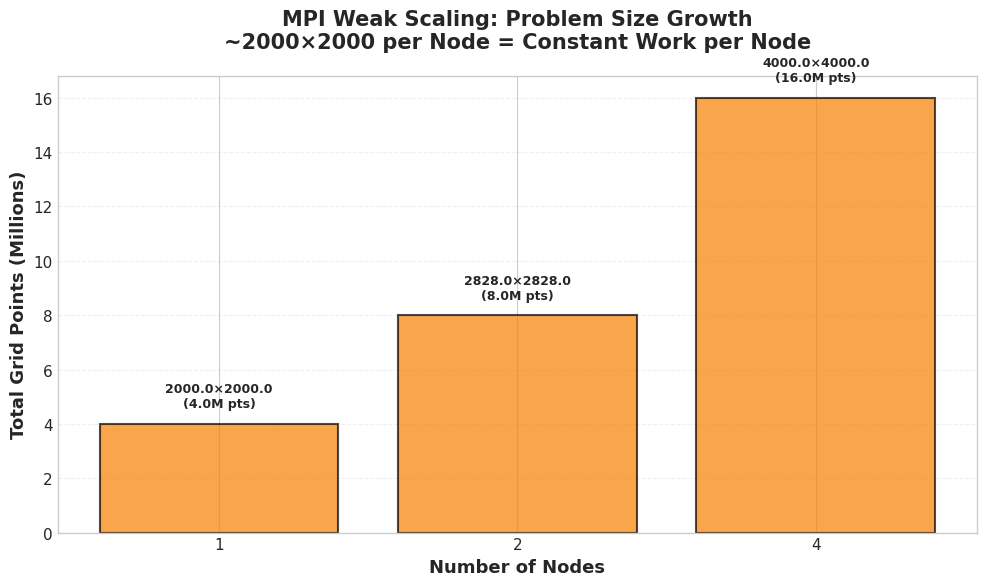

In [ ]:
# ============================================================================
# PLOT 5: Grid Size Scaling
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

df['TotalGridPoints'] = df['GridX'] * df['GridY']

ax.bar(df['Nodes'].astype(str), df['TotalGridPoints']/1e6, 
       color='#F77F00', alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Number of Nodes', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Grid Points (Millions)', fontsize=13, fontweight='bold')
ax.set_title('MPI Weak Scaling: Problem Size Growth\n~2000×2000 per Node = Constant Work per Node', 
             fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')

# Add grid size labels
for i, row in df.iterrows():
    total_pts = row['GridX'] * row['GridY'] / 1e6
    ax.text(i, total_pts + 0.5, 
            f"{row['GridX']}×{row['GridY']}\n({total_pts:.1f}M pts)",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('img/mpi_weak_gridsize.png', dpi=300, bbox_inches='tight')
print("✅ Saved: mpi_weak_gridsize.png")
plt.show()


In [8]:
print("\n" + "="*60)
print("MPI WEAK SCALING ANALYSIS SUMMARY")
print("="*60)
print(f"Problem Size per Node: ~2000×2000 (constant)")
print(f"Threads per Node: 128")
print(f"\nScaling Results (1 → {df['Nodes'].max()} nodes):")
print(f"  Final Efficiency: {df.iloc[-1]['Efficiency']*100:.1f}%")
print(f"  Time Variation: {df['TotalTime'].min():.3f}s → {df['TotalTime'].max():.3f}s")

if df['Efficiency'].max() > 1.0:
    print(f"\n⭐ SUPER-LINEAR EFFICIENCY DETECTED!")
    print(f"  Peak Efficiency: {df['Efficiency'].max()*100:.1f}% at {df.loc[df['Efficiency'].idxmax(), 'Nodes']} nodes")
    print(f"  Likely Cause: Better cache utilization with larger local domains")
else:
    print(f"\n✅ Good weak scaling maintained!")

print(f"\nCommunication Growth: {df.iloc[0]['CommTime']:.3f}s → {df.iloc[-1]['CommTime']:.3f}s")
print(f"  Increase: {(df.iloc[-1]['CommTime']/df.iloc[0]['CommTime'] - 1)*100:.1f}%")
print("="*60)


MPI WEAK SCALING ANALYSIS SUMMARY
Problem Size per Node: ~2000×2000 (constant)
Threads per Node: 128

Scaling Results (1 → 4 nodes):
  Final Efficiency: 110.3%
  Time Variation: 0.332s → 0.366s

⭐ SUPER-LINEAR EFFICIENCY DETECTED!
  Peak Efficiency: 110.3% at 4 nodes
  Likely Cause: Better cache utilization with larger local domains

Communication Growth: 0.038s → 0.075s
  Increase: 98.2%
